In [1]:
import sys
import pandas as pd

sys.path.append("..")
from scripts.database import engine

print("✅ Entorno listo")

QUERY = "SELECT * FROM pokemon"
df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados")
df.head()

✅ Conexión engine lista
✅ Entorno listo
✅ Datos cargados


,id,name,height,weight,base_experience,types
0,1,bulbasaur,7,69,64,"grass, poison"
1,2,ivysaur,10,130,142,"grass, poison"
2,3,venusaur,20,1000,236,"grass, poison"
3,4,charmander,6,85,62,fire
4,5,charmeleon,11,190,142,fire


In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               20 non-null     int64
 1   name             20 non-null     str  
 2   height           20 non-null     int64
 3   weight           20 non-null     int64
 4   base_experience  20 non-null     int64
 5   types            20 non-null     str  
dtypes: int64(4), str(2)
memory usage: 1.1 KB
None


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df["primary_type"] = df["types"].str.split(",").str[0].str.strip()

df["primary_type"].value_counts()

primary_type
bug       6
normal    5
grass     3
fire      3
water     3
Name: count, dtype: int64

In [4]:
df[["height", "weight", "base_experience"]].describe()

,height,weight,base_experience
count,20.000000,20.000000,20.000000
mean,9.050000,267.850000,124.600000
std,4.999737,301.904355,71.362234
min,3.000000,18.000000,39.000000
25%,5.750000,81.000000,62.750000
50%,8.500000,157.500000,132.000000
75%,11.000000,305.000000,178.000000
max,20.000000,1000.000000,240.000000


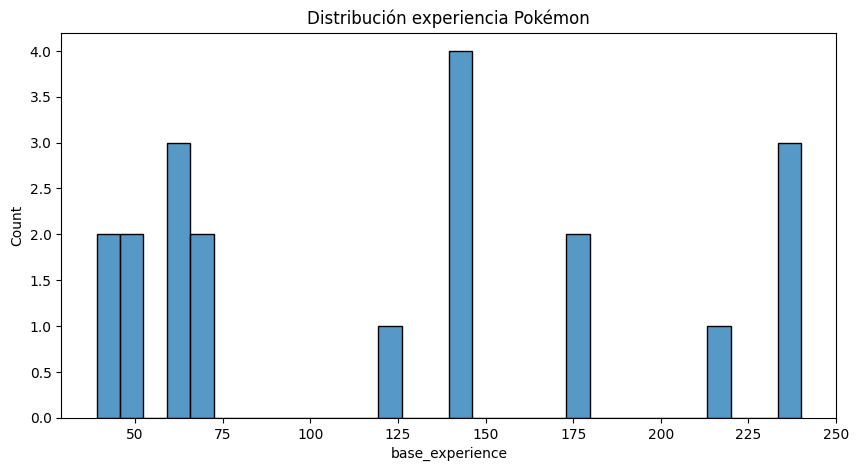

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["base_experience"], bins=30)
plt.title("Distribución experiencia Pokémon")
plt.show()

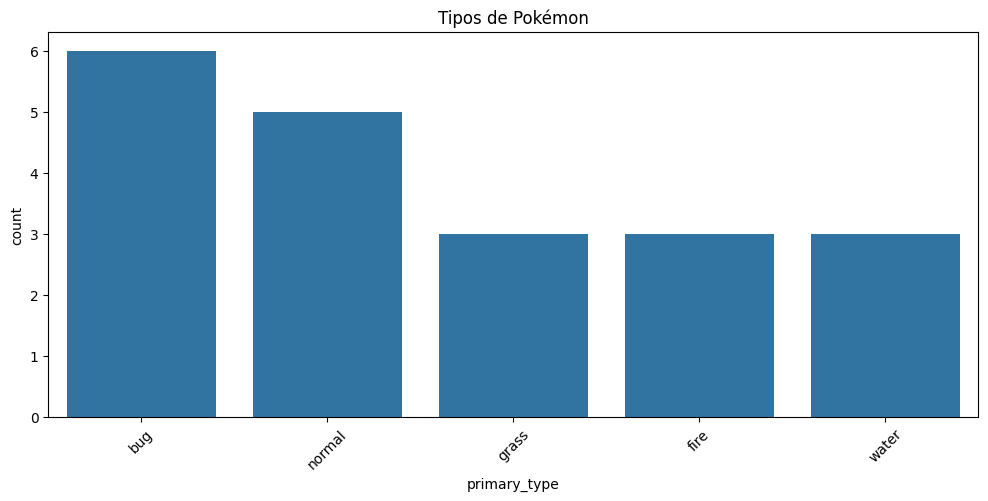

In [6]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="primary_type", order=df["primary_type"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Tipos de Pokémon")
plt.show()

In [7]:
vars_num = ["height", "weight", "base_experience"]

corr = df[vars_num].corr()
corr

,height,weight,base_experience
height,1.000000,0.916761,0.946504
weight,0.916761,1.000000,0.880466
base_experience,0.946504,0.880466,1.000000


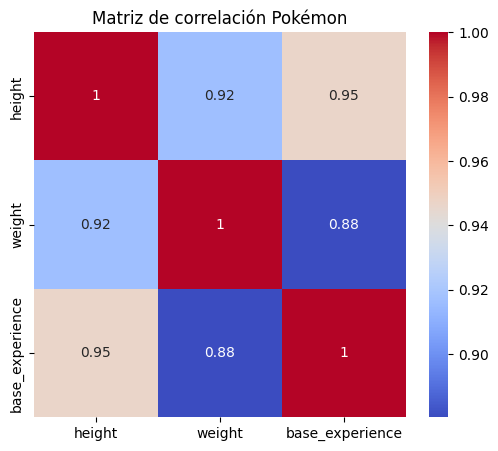

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación Pokémon")
plt.show()

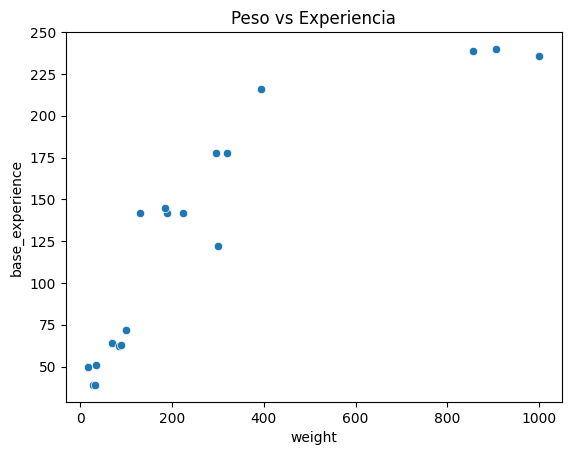

In [9]:
sns.scatterplot(data=df, x="weight", y="base_experience")
plt.title("Peso vs Experiencia")
plt.show()

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = df.dropna(subset=["height", "weight", "base_experience"])

X = df[["height", "weight"]]
y = df["base_experience"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Coeficientes 70-30:", model.coef_)
print("Intercepto 70-30:", model.intercept_)

print("=== RESULTADOS 70-30 ===")
print("R2:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE:", mean_absolute_error(y_test, pred))

Coeficientes 70-30: [13.52233113 -0.02322291]
Intercepto 70-30: 5.8783541364223595
=== RESULTADOS 70-30 ===
R2: 0.9063900764033711
RMSE: 24.156913355692165
MAE: 20.19344589347607


In [17]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.4, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)
print("Coeficientes 70-30:", model.coef_)
print("Intercepto 70-30:", model.intercept_)

print("=== RESULTADOS 60-40 ===")
print("R2:", r2_score(y_test2, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, pred2)))
print("MAE:", mean_absolute_error(y_test2, pred2))

Coeficientes 70-30: [13.52233113 -0.02322291]
Intercepto 70-30: 5.8783541364223595
=== RESULTADOS 60-40 ===
R2: 0.8758671763290693
RMSE: 26.81921308657059
MAE: 23.74571212361389


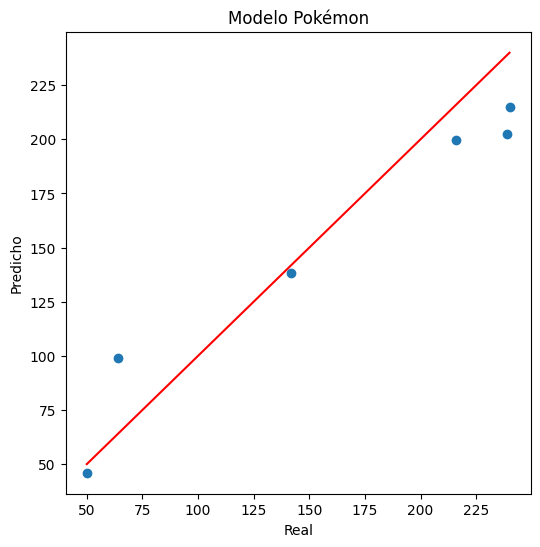

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Modelo Pokémon")
plt.show()

### Conclusión

Se evaluó el modelo de regresión lineal utilizando dos particiones de datos: 70-30 y 60-40.

Se observó que la partición 70-30 presentó mejores resultados en términos de R² y menor error, lo que indica una mejor capacidad de predicción del modelo.

Por lo tanto, se concluye que el modelo logra predecir la experiencia base de los Pokémon de manera aceptable utilizando las variables altura y peso, siendo la partición 70-30 la más adecuada para este caso.